In [1]:
import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import simpson
import pandas as pd
import os

from feos.eos import EquationOfState, State, Contributions
from feos.pets import PetsParameters
import si_units as si

import sys
sys.path.append("..")
import LJ_lmft_utils as lmft
import neural_utils as neural
import LJEOS as eos

# Enable or disable Tensor Float 32 Execution
tf.config.experimental.enable_tensor_float_32_execution(False)

2026-03-27 08:41:24.277001: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-27 08:41:24.389028: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774600884.427192    7552 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774600884.438255    7552 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-27 08:41:24.528536: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
def LJ_wall(position, low, high, epsilon=2, sigma=1):
    r_low = position - low
    r_high = high - position
    
    energy_low = 4 * epsilon * ((sigma / r_low)**12 - (sigma / r_low)**6)
    energy_high = 4 * epsilon * ((sigma / r_high)**12 - (sigma / r_high)**6)
    
    return np.where((position >= high) | (position <= low), 1e30, energy_low + energy_high)

    
def get_betaFexc(model_path, zbins, rho_A, rho_B, T, dx=0.005, L=30, rho_b_a = None, rho_b_b = None,
                  eps_AA=1.0, eps_BB=1.0, int_param=0.0, sigma_AA=1.0, sigma_BB=1.0, rc=2.5
                  ):
    """
    Calculate the excess free energy Fexc for a given density profile with functional line integration
    for a long range system using LMFT.

    model: The neural correlation functional
    rho: The density profile
    T: Temperature
    dx: The discretization of the input layer of the model
    L: Length of box
    rc: LJ cutoff
    rho_b: Bulk density to use to calculate mu_R for delta mu.
            If unspecified, assume confined fluid where rho_b is the value at the middle of the density profile.
    """

    model = keras.models.load_model(model_path)

    alphas = np.linspace(0, 1, 100)
    integrands = np.empty_like(alphas)

    if rho_b_a is None:
        rho_b_a = rho_A[int(len(rho_A)/2)] # Taken to be middle of slit

    if rho_b_b is None:
        rho_b_b = rho_B[int(len(rho_B)/2)]

    rho_tot = rho_b_a + rho_b_b
    beta = 1/T

    eps_AB = (1-int_param) * np.sqrt(eps_AA*eps_BB)
    sigma_AB = 0.5 * (sigma_AA + sigma_BB)

    potential_array_AA = lmft.attract(zbins, eps=eps_AA, sig=sigma_AA, cutoff=rc)
    potential_array_AB = lmft.attract(zbins, eps=eps_AB, sig=sigma_AB, cutoff=rc)
    potential_array_BB = lmft.attract(zbins, eps=eps_BB, sig=sigma_BB, cutoff=rc)

    for i, alpha in enumerate(alphas):

        # Calculate delta mu
        c1_sr_b = neural.c1_onetype_T(model, alpha*rho_tot*np.ones_like(rho_A), T*np.ones_like(rho_A), input_bins=1201)
        mu_R_A = np.log(alpha*rho_b_a) - c1_sr_b
        mu_R_B = np.log(alpha*rho_b_b) - c1_sr_b

        if alpha == 0:
            mu_correction_A = np.zeros_like(rho_A)
            mu_correction_B = np.zeros_like(rho_B)

        else:
            try:
                mu_LR = eos.calc_mu_mixture([alpha*rho_b_a, alpha*rho_b_b], T,
                                        np.array([eps_AA, eps_BB]),
                                        np.array([sigma_AA, sigma_BB]),
                                        k_ij = np.array([[0, int_param], [int_param, 0]]),
                                        )
                mu_A = mu_LR[0]
                mu_B = mu_LR[1]
                
                mu_correction_A = mu_A - T*mu_R_A
                mu_correction_B = mu_B - T*mu_R_B

            except RuntimeError as e:
                if "Invalid state in validate: moles = NaN" in str(e):
                    mu_correction_A = np.zeros_like(rho_A)
                    mu_correction_B = np.zeros_like(rho_B)
                else:
                    raise  # Re-raise if it's a different RuntimeError


        mu_correction_A[rho_A == 0] = 0
        mu_correction_B[rho_B == 0] = 0

        V_correction_AA = lmft.V_correction(dx, alpha*(rho_A - rho_b_a), potential_array_AA)
        V_correction_AB = lmft.V_correction(dx, alpha*(rho_B - rho_b_b), potential_array_AB)
        V_correction_BA = lmft.V_correction(dx, alpha*(rho_A - rho_b_a), potential_array_AB)
        V_correction_BB = lmft.V_correction(dx, alpha*(rho_B - rho_b_b), potential_array_BB)

        c1_pred_SR = neural.c1_onetype_T(model, alpha*(rho_A+rho_B), T*np.ones_like(rho_A), input_bins=1201)

        c1_LR_A = c1_pred_SR + beta*(V_correction_AA + V_correction_AB) - beta*mu_correction_A
        c1_LR_B = c1_pred_SR + beta*(V_correction_BB + V_correction_BA) - beta*mu_correction_B

        integrands[i] = np.sum(rho_A * c1_LR_A + rho_B * c1_LR_B) * dx
        
    Fexc = -simpson(integrands, x=alphas)

    return Fexc, c1_LR_A, c1_LR_B


def get_beta_omega(model_path, xbins, rho_A, rho_B, T, mu_A, mu_B, Vext_A, Vext_B, L=30, rho_bulk_A=None, rho_bulk_B = None,
              eps_AA=1.0, eps_BB=1.0, int_param=0.0, sigma_AA=1.0, sigma_BB=1.0, rc=2.5
              ):
    # This is the beta grand potential per unit area

    Fex, c1_LR_A, c1_LR_B = get_betaFexc(model_path, xbins, rho_A, rho_B, T, rho_b_a = rho_bulk_A, rho_b_b = rho_bulk_B,
                                          eps_AA=eps_AA, eps_BB=eps_BB, int_param=int_param,
                                          sigma_AA=sigma_AA, sigma_BB=sigma_BB, rc=rc
                                            )

    valid_A = (rho_A != 0)
    valid_B = (rho_B != 0)

    Fid = (np.trapezoid(rho_A[valid_A] * (np.log(rho_A[valid_A]) - 1), x=xbins[valid_A]) +
             np.trapezoid(rho_B[valid_B] * (np.log(rho_B[valid_B]) - 1), x=xbins[valid_B]) )

    integral = np.trapezoid(rho_A[valid_A] * (Vext_A[valid_A] - mu_A), x=xbins[valid_A]) + np.trapezoid(rho_B[valid_B] * (Vext_B[valid_B] - mu_B), x=xbins[valid_B])

    return Fid + Fex + integral


def pred_gamma(omega, pressure, H):
    return 0.5 * (omega + pressure*H)

In [3]:
def integrate_profile(df, x_min, x_max, column="rho_A"):
    """
    Integrate the density profile between x_min and x_max to get Gamma.
    """
    mask = df["x_centered"].between(x_min, x_max)
    sub = df.loc[mask].sort_values("x_centered")
    return np.trapezoid(sub[column], x=sub["x_centered"])


def compute_H_from_profile(df_rho, rho_bulk, column="rho_B", H_min=None, H_max=None):
    """
    Integrate the density over a range of trial H values and fit Gamma vs H
    to find the H where Gamma = 0.
    """
    if H_min is None:
        H_min = 0.0
    if H_max is None:
        H_max = df_rho["x_centered"].max() - df_rho["x_centered"].min()

    Hrange = np.arange(H_min, H_max, 0.01)
    results = []

    for H in Hrange:
        Gamma = integrate_profile(df_rho, -0.5*H, 0.5*H, column=column) - H*rho_bulk
        results.append((H, Gamma))

    df_ads = pd.DataFrame(results, columns=["H", "Gamma"])

    # Fit linearly near the maximum H to find zero crossing
    df_fit = df_ads.loc[df_ads["H"].between(Hrange[-10], Hrange[-1])]
    coeffs = np.polyfit(df_fit["H"], df_fit["Gamma"], 1)

    H_zero = -coeffs[1] / coeffs[0]
    return H_zero, df_ads

## Symmetric walls
#### Set up parameters and equation of state

In [4]:
eps_AA = 1.0
eps_BB = 0.9
int_param = 0.15
sigma = np.ones((2))

parameters = PetsParameters.from_lists(sigma = sigma,
                                       epsilon_k = np.array([eps_AA, eps_BB]),
                                       k_ij = np.array([[0, int_param], [int_param, 0]])
                                       )

pets_azeo = EquationOfState.pets(parameters)

In [5]:
mol_frac = np.linspace(0.02, 0.98, num = 25)
T = 0.77
p = 0.0248

model_path = "../../models/WCA.keras"

width = 1.5
L = 8.0
eps_w = 2.0

#### Extract thermodynamics

In [6]:
S_A = np.empty_like(mol_frac)
S_B = np.empty_like(mol_frac)
rhobar = np.empty_like(mol_frac)
mu_A = np.empty_like(mol_frac)
mu_B = np.empty_like(mol_frac)
omega = np.empty_like(mol_frac)
gamma = np.empty_like(mol_frac)
GammaA_B = np.empty_like(mol_frac)

###### Obtain H from S_B = 1 i.e. the azeotropic point

x_az = 0.66

s = State(
    eos=pets_azeo,
    temperature=T*si.KELVIN,
    molefracs = np.array([1-x_az, x_az]),
    pressure = p * (si.KELVIN * si.KB / si.ANGSTROM**3)
    )

rhobar_azeo = s.density * si.NAV * si.ANGSTROM**3
rho_mixture = rhobar_azeo*np.array([1-x_az, x_az])

df_rho = pd.read_csv(f"../../data/mixtures/selectivity/same_eps_w/" \
                     f"T{T:.2f}/{p:.4f}/capillary_{eps_w:.1f}/{x_az:.2f}/" \
                     f"profiles/lr_pred_capillary_{L+2*width:.2f}_1.out", sep= " ")

df_rho["x_centered"] = df_rho["xbins"] - df_rho["xbins"].mean()
H, _ = compute_H_from_profile(df_rho, rho_mixture[1], column="rho_B", H_min=L-6, H_max=L+10)

for i, x in enumerate(mol_frac):

    s = State(
        eos=pets_azeo,
        temperature=T*si.KELVIN,
        molefracs = np.array([1-x, x]),
        pressure = p * (si.KELVIN * si.KB / si.ANGSTROM**3)
        )

    rho_tot = s.density * si.NAV * si.ANGSTROM**3
    rhobar[i] = rho_tot
    rho_mixture = rho_tot*np.array([1-x, x])
    betamu = s.chemical_potential(Contributions.Residual) / (si.RGAS* T*si.KELVIN) + np.log(rho_mixture)
    mu_A[i] = betamu[0]*T
    mu_B[i] = betamu[1]*T

    file_name = f"../../data/mixtures/selectivity/same_eps_w/" \
                     f"T{T:.2f}/{p:.4f}/capillary_{eps_w:.1f}/{x:.2f}/" \
                     f"profiles/lr_pred_capillary_{L+2*width:.2f}_1.out"
    
    df = pd.read_csv(file_name, sep= " ")

    xbins = df["xbins"].to_numpy()
    rho_A = df["rho_A"].to_numpy()
    rho_B = df["rho_B"].to_numpy()

    Vext_A = LJ_wall(xbins, width, L+width, eps_w)
    Vext_B = LJ_wall(xbins, width, L+width, eps_w)

    omega[i] = get_beta_omega(model_path, xbins, rho_A, rho_B, T,
                            betamu[0], betamu[1], Vext_A, Vext_B, L,
                            rho_bulk_A = rho_mixture[0], rho_bulk_B = rho_mixture[1],
                            eps_AA=eps_AA, eps_BB=eps_BB, int_param=int_param)

    N_A = np.trapezoid(rho_A, x=xbins) / L
    N_B = np.trapezoid(rho_B, x=xbins) / L
    N_tot = N_A + N_B

    x_A_slit = N_A/N_tot
    x_B_slit = N_B/N_tot

    S_A[i] = x_A_slit / (1 - x)
    S_B[i] = x_B_slit / x

    df_rho = df
    df_rho["x_centered"] = df_rho["xbins"] - df_rho["xbins"].mean()

    GammaA = integrate_profile(df_rho, -0.5*H, 0.5*H, column="rho_A") - H*rho_mixture[0]
    GammaB = integrate_profile(df_rho, -0.5*H, 0.5*H, column="rho_B") - H*rho_mixture[1]

    gamma[i] = pred_gamma(T*omega[i], p, H)

    GammaA_B[i] = GammaA - (rho_mixture[0]/rho_mixture[1]) * GammaB

2026-03-10 13:04:47.526392: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
I0000 00:00:1773147887.697770   13062 service.cc:148] XLA service 0x7b702c025ed0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773147887.697949   13062 service.cc:156]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1773147887.770573   13062 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
/tmp/ipykernel_12983/2104447375.py:53: RuntimeWarning: divide by zero encountered in log
  mu_R_A = np.log(alpha*rho_b_a) - c1_sr_b
/tmp/ipykernel_12983/2104447375.py:54: RuntimeWarning: divide by zero encountered in log
  mu_R_B = np.log(alpha*rho_b_b) - c1_sr_b
/tmp/ipykernel_12983/2104447375.py:53: RuntimeWarning: divide by zero encountered in log
  mu_R_A = np.log(alpha*rho_b_a) - 

In [7]:

np.savetxt(f"../../data/mixtures/selectivity/same_eps_w/" \
            f"T{T:.2f}/{p:.4f}/capillary_{eps_w:.1f}/thermodynamics.dat",
           np.c_[mol_frac, rhobar, mu_A, S_A, S_B, omega, gamma, GammaA_B],
            delimiter=" ",
            header="xB rhobar mu_A S_A S_B omega gamma GammaA_B",
            comments="",
            fmt=['%.2f', '%.20f', '%.20f', '%.20f', '%.20f', '%.20f', '%.20f', '%.20f'])


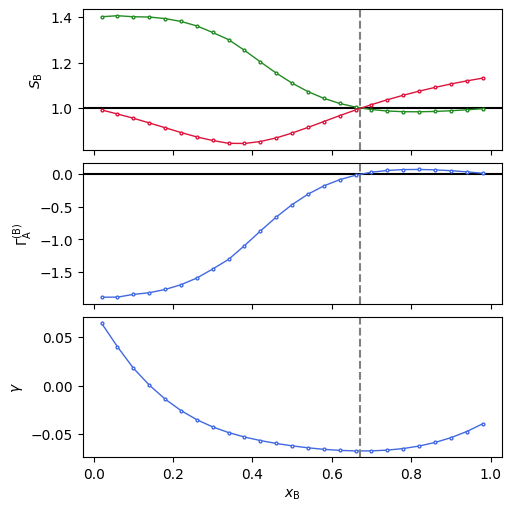

In [8]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(5, 5), sharex=True, layout="constrained")

axs[0].plot(mol_frac, S_B, '-o', markersize=2, color="forestgreen", lw=1, markerfacecolor="white")
axs[0].plot(mol_frac, S_A, '-o', markersize=2, color="crimson", lw=1, markerfacecolor="white")

axs[1].plot(mol_frac, GammaA_B, '-o', markersize=2, color="royalblue", lw=1, markerfacecolor="white")
axs[2].plot(mol_frac, gamma, '-o', markersize=2, color="royalblue", lw=1, markerfacecolor="white")

for i in range(3):
    axs[i].axvline(0.67, color="grey", linestyle="dashed")

axs[0].axhline(1.0, color="black", zorder=0)
axs[1].axhline(0.0, color="black", zorder=0)

axs[0].set_ylabel(r"$ S_{\text{B}}$")
axs[1].set_ylabel(r"$ \Gamma_{\text{A}}^{\text{(B)}}$")
axs[2].set_ylabel(r"$ \gamma$")

axs[2].set_xlabel(r"$x_{\text{B}}$") 

plt.show()


## Asymmetric walls

In [4]:

def find_zero_crossings(x_data, y_data):
    zero_crossings = []
    for i in range(len(x_data) - 1):
        x0, y0 = x_data[i], y_data[i]
        x1, y1 = x_data[i + 1], y_data[i + 1]
        if y0 == 0:
            zero_crossings.append(x0)
        elif y0 * y1 < 0:
            x_zero = x0 - y0 * (x1 - x0) / (y1 - y0)
            zero_crossings.append(x_zero)
    if y_data[-1] == 0:
        zero_crossings.append(x_data[-1])
    if zero_crossings == []:
        zero_crossings = [np.nan]
    return zero_crossings

def calculate_cross_points(eps_B, eps_wall_A, L_range, mol_frac):
    # L here is the actual slit width
    
    oversolubility_B = np.full((len(L_range), len(eps_wall_A), len(mol_frac)), np.nan)
    cross_point = np.full((len(L_range), len(eps_wall_A)), np.nan)

    # Loop over slit widths
    for l, L in enumerate(L_range):
        for a, x in enumerate(mol_frac):
            for i, eps_A in enumerate(eps_wall_A):
                df_select = pd.read_csv(
                    f"../../data/mixtures/selectivity/varying_eps_w/{eps_B:.3f}/capillary_{eps_A:.3f}/{x:.2f}/oversolubility.dat",
                    delimiter=" ", header=None, skiprows=1
                )
                idx_select = abs(df_select[0] - (L+2*width)).idxmin()
                oversolubility_B[l, i, a] = df_select[7][idx_select]

        for i in range(len(eps_wall_A)):
            cross_point[l, i] = find_zero_crossings(mol_frac, oversolubility_B[l, i, :]-1)[0]

    return cross_point, oversolubility_B


def get_SB(eps_B, eps_wall, L, mol_frac, T, pressure):
    # L here is the actual slit width
  
    S_A = np.empty((len(eps_wall), len(mol_frac)))
    S_B =  np.empty((len(eps_wall), len(mol_frac)))
    rhobar =  np.empty_like(mol_frac)
    mu_A =  np.empty_like(mol_frac)

    for a, x in enumerate(mol_frac):
        s = State(
        eos=pets_azeo,
        temperature=T*si.KELVIN,
        molefracs = np.array([1-x, x]),
        pressure = pressure * (si.KELVIN * si.KB / si.ANGSTROM**3)
        )

        rho_tot = s.density * si.NAV * si.ANGSTROM**3
        rhobar[a] = rho_tot
        rho_mixture = rho_tot*np.array([1-x, x])
        betamu = s.chemical_potential(Contributions.Residual) / (si.RGAS* T*si.KELVIN) + np.log(rho_mixture)
        mu_A[a] = betamu[0]*T

        for i, eps in enumerate(eps_wall):

            filename = f"../../data/mixtures/selectivity/varying_eps_w/{eps_B:.3f}/capillary_{eps:.3f}/" \
                        f"{x:.2f}/profiles/lr_pred_capillary_{L+2*width:.2f}_1.out"
            
            df = pd.read_csv(filename, sep= " ")

            xbins = df["xbins"].to_numpy()
            rho_A = df["rho_A"].to_numpy()
            rho_B = df["rho_B"].to_numpy()
        
    
            N_A = np.trapezoid(rho_A, x=xbins) / L
            N_B = np.trapezoid(rho_B, x=xbins) / L
            N_tot = N_A + N_B

            x_A_slit = N_A/N_tot
            x_B_slit = N_B/N_tot

            S_A[i, a] = x_A_slit / (1 - x)
            S_B[i, a] = x_B_slit / x

    return S_B


def get_properties(eps_B, eps_A_range, L, mol_frac, T, pressure, x_an):
    # L here is the actual slit width
  
    S_A = np.empty((len(eps_A_range), len(mol_frac)))
    S_B =  np.empty((len(eps_A_range), len(mol_frac)))
    rhobar =  np.empty_like(mol_frac)
    mu_A =  np.empty_like(mol_frac)
    gamma =  np.empty((len(eps_A_range), len(mol_frac)))
    H =  np.empty_like(eps_A_range) # H varies with delta eps_w
    GammaA =  np.empty((len(eps_A_range), len(mol_frac)))
    GammaB =  np.empty((len(eps_A_range), len(mol_frac)))
    GammaA_B =  np.empty((len(eps_A_range), len(mol_frac)))
    omega = np.empty((len(eps_A_range), len(mol_frac)))

    x_nearest = mol_frac[np.argmin(np.abs(mol_frac - x_an))]
    s = State(
        eos=pets_azeo,
        temperature=T*si.KELVIN,
        molefracs = np.array([1-x_an, x_an]),
        pressure = pressure * (si.KELVIN * si.KB / si.ANGSTROM**3)
        )

    rho_tot = s.density * si.NAV * si.ANGSTROM**3
    rho_mixture = rho_tot*np.array([1-x_an, x_an])
    betamu = s.chemical_potential(Contributions.Residual) / (si.RGAS* T*si.KELVIN) + np.log(rho_mixture)
    
    #### Obtain H
    for i, eps_A in enumerate(eps_A_range):
        filename = f"../../data/mixtures/selectivity/varying_eps_w/{eps_B:.3f}/capillary_{eps_A:.3f}/" \
                    f"{x_nearest:.2f}/profiles/lr_pred_capillary_{L+2*width:.2f}_1.out"
        df_rho = pd.read_csv(filename, sep= " ")
        df_rho["x_centered"] = df_rho["xbins"] - df_rho["xbins"].mean()
        H[i], _ = compute_H_from_profile(df_rho, rho_mixture[1], column="rho_B", H_min=L-6, H_max=L+10)

    #### Obtain other properties
    for a, x in enumerate(mol_frac):
        s = State(
        eos=pets_azeo,
        temperature=T*si.KELVIN,
        molefracs = np.array([1-x, x]),
        pressure = pressure * (si.KELVIN * si.KB / si.ANGSTROM**3)
        )

        rho_tot = s.density * si.NAV * si.ANGSTROM**3
        rhobar[a] = rho_tot
        rho_mixture = rho_tot*np.array([1-x, x])
        betamu = s.chemical_potential(Contributions.Residual) / (si.RGAS* T*si.KELVIN) + np.log(rho_mixture)
        mu_A[a] = betamu[0]*T

        for i, eps_A in enumerate(eps_A_range):

            filename = f"../../data/mixtures/selectivity/varying_eps_w/{eps_B:.3f}/capillary_{eps_A:.3f}/" \
                        f"{x:.2f}/profiles/lr_pred_capillary_{L+2*width:.2f}_1.out"
            
            df = pd.read_csv(filename, sep= " ")

            xbins = df["xbins"].to_numpy()
            rho_A = df["rho_A"].to_numpy()
            rho_B = df["rho_B"].to_numpy()
            
            omega_path = f"../../data/mixtures/selectivity/varying_eps_w/{eps_B:.3f}/capillary_{eps_A:.3f}/{x:.2f}/grand_potential.dat"
            if os.path.exists(omega_path):
                df_omega = pd.read_csv(omega_path,
                                    delimiter=" ", header=None, skiprows=1)
                idx_select = abs(df_omega[0] - (L+2*width)).idxmin()
                omega[i, a] = df_omega[1][idx_select] # omega
            else:
                print(f"Not found omega for eps_B {eps_B:.3f} eps_A {eps_A:.3f} x {x:.2f}; calculating...")
                Vext_A = LJ_wall(xbins, width, L+width, eps_A)
                Vext_B = LJ_wall(xbins, width, L+width, eps_B)
                # beta omega
                omega[i, a] = get_beta_omega(model_path, xbins, rho_A, rho_B, T,
                            betamu[0], betamu[1], Vext_A, Vext_B, L,
                            rho_bulk_A = rho_mixture[0], rho_bulk_B = rho_mixture[1],
                            eps_AA=eps_AA, eps_BB=eps_BB, int_param=int_param)
                omega[i, a] = T*omega[i, a]
    
            N_A = np.trapezoid(rho_A, x=xbins) / L
            N_B = np.trapezoid(rho_B, x=xbins) / L
            N_tot = N_A + N_B

            x_A_slit = N_A/N_tot
            x_B_slit = N_B/N_tot

            S_A[i, a] = x_A_slit / (1 - x)
            S_B[i, a] = x_B_slit / x

            df_rho = df
            df_rho["x_centered"] = df_rho["xbins"] - df_rho["xbins"].mean()

            GammaA[i, a] = integrate_profile(df_rho, -0.5*H[i], 0.5*H[i], column="rho_A") - H[i]*rho_mixture[0]
            GammaB[i, a] = integrate_profile(df_rho, -0.5*H[i], 0.5*H[i], column="rho_B") - H[i]*rho_mixture[1]

            gamma[i, a] = pred_gamma(omega[i, a], pressure, H[i])

        GammaA_B[:, a] = GammaA[:, a] - (rho_mixture[0]/rho_mixture[1]) * GammaB[:, a]

    return S_B, GammaA_B, gamma, rhobar, mu_A, H, omega

#### Set up parameters and equation of state

In [5]:
eps_AA = 1.0
eps_BB = 0.9
int_param = 0.15
sigma = np.ones((2))

parameters = PetsParameters.from_lists(sigma = sigma,
                                       epsilon_k = np.array([eps_AA, eps_BB]),
                                       k_ij = np.array([[0, int_param], [int_param, 0]])
                                       )

pets_azeo = EquationOfState.pets(parameters)

In [6]:
T = 0.77
p = 0.0248
L = 8.0
width = 1.5
model_path = "../../models/WCA.keras"

mol_frac = np.linspace(0.02, 0.98, num=25) 
mol_frac2 = np.linspace(0.01, 0.99, num=99) # Smaller discretisation for S_B/gamma/Gamma_A^(B) vs xB plots

In [7]:
eps_wall_A_to_plot = [1.8, 2.0, 2.2]
S_B = get_SB(2.0, eps_wall_A_to_plot, L, mol_frac2, T, p)


delta_eps_w = np.linspace(-0.5, 0.5, num=51)
L_to_plot = [5.0, 8.0, 20.0, 50.0]
eps_B_range = [2.0]

In [8]:
#### Calculate aneotrope for varying delta_eps_w and L
x_an = []
for j, eps_B in enumerate(eps_B_range):
    eps_wall_range_A = eps_B - delta_eps_w
    cross_point, _ = calculate_cross_points(eps_B, eps_wall_range_A, L_to_plot, mol_frac)
    x_an.append(cross_point)

x_an = np.array(x_an)

#### Get H and S_B for varying delta_eps_w and L

x_az = 0.67

s = State(
    eos=pets_azeo,
    temperature=T*si.KELVIN,
    molefracs = np.array([1-x_az, x_az]),
    pressure = p * (si.KELVIN * si.KB / si.ANGSTROM**3)
    )

rhobar_azeo = s.density * si.NAV * si.ANGSTROM**3
rho_mixture = rhobar_azeo*np.array([1-x_az, x_az])

SB_vary = np.empty((len(eps_B_range), len(delta_eps_w), len(L_to_plot)))
H_vary = np.empty((len(eps_B_range), len(L_to_plot)))


for j, eps_B in enumerate(eps_B_range):
    for l, SB_L in enumerate(L_to_plot):
        filename = f"../../data/mixtures/selectivity/varying_eps_w/{eps_B:.3f}/capillary_{eps_B:.3f}/" \
                        f"{x_az:.2f}/profiles/lr_pred_capillary_{SB_L+2*width:.2f}_1.out"
        df_rho = pd.read_csv(filename, sep= " ")
        df_rho["x_centered"] = df_rho["xbins"] - df_rho["xbins"].mean()
        H_vary[j, l], _ = compute_H_from_profile(df_rho, rho_mixture[1], column="rho_B", H_min=SB_L-6, H_max=SB_L+10)

for j, eps_B in enumerate(eps_B_range):
    for i, del_eps in enumerate(delta_eps_w):
        eps_A = eps_B - del_eps

        for l, SB_L in enumerate(L_to_plot):

            filename = f"../../data/mixtures/selectivity/varying_eps_w/{eps_B:.3f}/capillary_{eps_A:.3f}/" \
                        f"{x_az:.2f}/profiles/lr_pred_capillary_{SB_L+2*width:.2f}_1.out"
            df = pd.read_csv(filename, sep= " ")

            xbins = df["xbins"].to_numpy()
            rho_A = df["rho_A"].to_numpy()
            rho_B = df["rho_B"].to_numpy()

            N_A = np.trapezoid(rho_A, x=xbins) / SB_L
            N_B = np.trapezoid(rho_B, x=xbins) / SB_L
            N_tot = N_A + N_B
            
            x_A_slit = N_A/N_tot
            x_B_slit = N_B/N_tot

            SB_vary[j, i, l] = x_B_slit / x_az

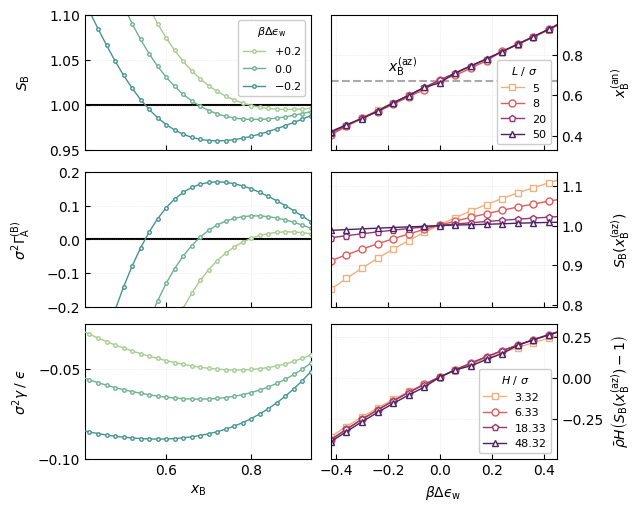

In [10]:

fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(6.3, 5), sharex="col", layout="constrained")
axs = ax.flatten()


############## Varying delta eps_w ##############

plot_colour_B2 = sns.color_palette("flare", as_cmap=True)(np.linspace(0, 1, len(L_to_plot)))
cmap_A = sns.color_palette("flare", as_cmap=True)
plot_colour_A = cmap_A(np.linspace(0, 1, len(L_to_plot)))
plot_every = 3
shapes = ["s", "o", "p", "^"]

for i, eps_B in enumerate(eps_B_range):
    for j, L in enumerate(L_to_plot):
        axs[1].plot(delta_eps_w[1::plot_every], x_an[i][j][1::plot_every], color=plot_colour_B2[j],
                   markersize = 5, markerfacecolor="white", lw=1, label=f"{L:.0f}" if i == 0 else "",
                   marker=shapes[j])
        
        axs[3].plot(delta_eps_w[1::plot_every], SB_vary[i, :, j][1::plot_every], markersize=5, color=plot_colour_A[j], lw=1, markerfacecolor="white",
                    marker=shapes[j])
        
        y = H_vary[i, j]*rhobar_azeo*(SB_vary[i, :, j] - 1)
        axs[5].plot(delta_eps_w[1::plot_every], y[1::plot_every], markersize=5, color=plot_colour_A[j], lw=1, markerfacecolor="white",
                label=f"{H_vary[i, j]:.2f}", marker=shapes[j])


axs[1].legend(title="$L$ / $\\sigma$", fontsize=8, title_fontsize=8, facecolor="white", framealpha=1,)
axs[5].legend(title="$H$ / $\\sigma$", fontsize=8, title_fontsize=8, facecolor="white", framealpha=1,)



############## Varying x_B and delta eps_w ##############

cmap_B3 = sns.color_palette("crest", as_cmap=True)
plot_colour_B = cmap_B3(np.linspace(0, 1, 6))
plot_every = 2

for i in range(len(eps_wall_A_to_plot)):
    mid_idx = len(eps_wall_A_to_plot) // 2

    axs[0].plot(mol_frac2[1::plot_every], S_B[i][1::plot_every], '-o',
                markersize=2.5, color=plot_colour_B[i],
                lw=1, markerfacecolor="white",
                label="$+0.2$" if i == 0 else f"${2.0 - eps_wall_A_to_plot[i]:.1f}$")


    x_zero_SB = find_zero_crossings(mol_frac2, S_B[i]-1)

    for x0 in x_zero_SB:

        S_B2, GammaA, gamma, rhobar, mu_A, H_list, omega = get_properties(2.0, [eps_wall_A_to_plot[i]], 8.0, mol_frac2, T, p, x0)

        axs[2].plot(mol_frac2[1::plot_every], GammaA[0][1::plot_every], '-o',
                markersize=2.5, color=plot_colour_B[i],
                lw=1, markerfacecolor="white",
                )

        axs[4].plot(mol_frac2[1::plot_every], gamma[0][1::plot_every], '-o',
                markersize=2.5, color=plot_colour_B[i],
                lw=1, markerfacecolor="white", zorder=10
                )


axs[0].legend(loc="upper right", fontsize=8,facecolor="white", framealpha=1,
              title=r"$\beta \Delta ϵ_{\text{w}}$",  title_fontsize=8)

axs[0].axhline(1.0, color="black", zorder=0)
axs[2].axhline(0.0, color="black", zorder=0)
axs[1].axhline(0.67, color="darkgrey", linestyle="dashed", zorder=0)

##############


for i in range(len(axs)):
    axs[i].tick_params(direction="in")
    axs[i].grid(alpha=0.4, linestyle="dotted", lw=0.5)
    axs[i].set_axisbelow(True)

axs[0].set_ylabel(r"$ S_{\text{B}}$")
axs[2].set_ylabel(r"$ \sigma^2 \Gamma_{\text{A}}^{\text{(B)}}$")
axs[4].set_ylabel(r"$ \sigma^2 \gamma \; / \; ϵ $")

axs[1].set_ylabel(r"$ x^{\text{(an)}}_{\text{B}}$")
axs[3].set_ylabel(r"$ S_{\text{B}} (x^{\text{(az)}}_{\text{B}})$")
axs[5].set_ylabel(r"$ \bar{\rho} H \left( S_{\text{B}} (x^{\text{(az)}}_{\text{B}}) -1 \right)$")

axs[4].set_xlabel(r"$x_{\text{B}}$")
axs[5].set_xlabel(r"$\beta \Delta ϵ_{\text{w}}$")


for ax in [axs[1], axs[3], axs[5]]:
    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()

fig.align_ylabels([axs[0], axs[2], axs[4]])
fig.align_ylabels([axs[1], axs[3], axs[5]])

axs[0].set_xlim(0.41, 0.94)

axs[0].set_ylim(0.95, 1.1)
axs[2].set_ylim(-0.2, 0.2)

axs[4].set_ylim(top=-0.025)
axs[4].set_yticks([-0.05,-0.1])

axs[1].set_xlim(-0.42, 0.45)

axs[1].annotate("$x_{\\text{B}}^{\\text{(az)}}$", (-0.2, 0.72), fontsize=10)

plt.show()
